# Analisis Sentimen Ulasan inDriver (Google Play Store) - Tahun 2026

Notebook ini berisi analisis ulasan pengguna inDriver di Indonesia sepanjang tahun 2026 untuk menjawab 6 Rumusan Masalah utama terkait kinerja teknis, aspek bisnis, dan responsivitas layanan pelanggan.

In [1]:
!pip install Sastrawi wordcloud vaderSentiment


[notice] A new release of pip is available: 23.2.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip


In [2]:
import pandas as pd
import numpy as np
import re
import nltk
import matplotlib.pyplot as plt
import seaborn as sns
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory
from collections import Counter
from wordcloud import WordCloud

nltk.download('punkt')
nltk.download('stopwords')

# Set style visualisasi
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 11

/opt/anaconda3/lib/python3.11/site-packages/pandas/core/computation/expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.8.7' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
/opt/anaconda3/lib/python3.11/site-packages/pandas/core/arrays/masked.py:56: UserWarning: Pandas requires version '1.4.2' or newer of 'bottleneck' (version '1.3.7' currently installed).
  from pandas.core import (
[nltk_data] Downloading package punkt to /Users/asyzyni/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/asyzyni/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


# Load Lexicon InSet

In [3]:
neg_inset = pd.read_csv("/Users/asyzyni/Desktop/Sentimen_analysis_sdpi/lexicons/InSet Lexicon/negative.tsv", sep="\t")
pos_inset = pd.read_csv("/Users/asyzyni/Desktop/Sentimen_analysis_sdpi/lexicons/InSet Lexicon/positive.tsv", sep="\t")
print(f"Negative Lexicon: {len(neg_inset)} words, Positive Lexicon: {len(pos_inset)} words")

Negative Lexicon: 6609 words, Positive Lexicon: 3609 words


# Load Dataset Ulasan inDriver

In [4]:
df = pd.read_csv("/Users/asyzyni/Desktop/Sentimen_analysis_sdpi/data/reviews_playstore_indrive_2026.csv")
print("Shape dataset:", df.shape)
print("Missing values per kolom:")
print(df.isnull().sum())
df.head()

Shape dataset: (9927, 11)
Missing values per kolom:
reviewId                   0
userName                   0
userImage                  0
content                    0
score                      0
thumbsUpCount              0
reviewCreatedVersion    1530
at                         0
replyContent            5687
repliedAt               5687
appVersion              1530
dtype: int64


,reviewId,userName,userImage,content,score,thumbsUpCount,reviewCreatedVersion,at,replyContent,repliedAt,appVersion
0,295d6711-b65d-4c3b-97d0-3f98c507b329,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,tolong fitur pengurangan argo dari harga norma...,5,2,5.170.0,2026-06-04 09:06:19,NaN,NaN,5.170.0
1,548bec7f-f837-43d6-ae48-e3d66ea211ea,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,1. maraknya driver yang menggunakan mod membua...,4,4,5.169.1,2026-05-30 01:25:11,Halo! Terima kasih atas masukan detail Anda. K...,2026-05-30 02:11:57,5.169.1
2,c1f900c3-a77c-42d7-98cd-76ffaecb7650,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,"Saya driver baru, sebenarnya konsep indrive in...",4,15,5.161.0,2026-03-31 18:31:56,Halo! Senang sekali mendengar Anda menyukai ko...,2026-03-31 20:31:46,5.161.0
3,8bfde163-d061-408e-a97e-97ced4e34655,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,"aplikasi gimana udah di update, malah makin re...",5,6,5.169.1,2026-06-03 08:25:45,NaN,NaN,5.169.1
4,ff05c1be-59a4-48bc-affc-5cda7a518d4d,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,"ini sistem sudah tidak fair lagi sekarang, unt...",1,139,5.168.0,2026-05-14 14:18:31,Halo! Terima kasih atas masukan Anda mengenai ...,2026-05-14 16:27:07,5.168.0


# Preprocessing & Pembersihan Data (Prompt 1)

Pada tahap ini kita akan:
1. Mempertahankan kolom penting: `reviewCreatedVersion`, `at`, `thumbsUpCount`, `replyContent`, `repliedAt`.
2. Melakukan pembersihan teks (case folding, URL removal, special char removal, stopword removal).
3. Melakukan stemming menggunakan Sastrawi dengan optimasi caching untuk mempercepat eksekusi.
4. Mengonversi tipe data tanggal ke datetime.
5. Menghitung `response_time_hours` (menghapus nilai negatif sebagai anomali) dan membuat kolom flag `is_replied`.

In [5]:
class OptimizedPreprocessor:
    def __init__(self):
        self.stemmer = StemmerFactory().create_stemmer()
        self.stop_words = set(stopwords.words('indonesian'))
        custom_stopwords = {'nya', 'yg', 'ya', 'aja', 'nih', 'dong', 'deh', 'lah', 'sih', 'kok', 'kan', 'pun'}
        self.stop_words.update(custom_stopwords)
        self.stem_cache = {}

    def clean_text(self, text):
        if not isinstance(text, str):
            return ""
        text = text.lower()
        text = re.sub(r"http\S+|www\S+", "", text)
        text = re.sub(r"@\w+|#\w+", "", text)
        text = re.sub(r"\d+", "", text)
        text = re.sub(r"[^\w\s]", " ", text)
        text = re.sub(r"\s+", " ", text).strip()
        return text

    def preprocess_corpus(self, df_col):
        print("1. Cleaning text...")
        cleaned_texts = df_col.apply(self.clean_text)
        
        print("2. Tokenizing and filtering stopwords...")
        tokenized_corpus = []
        all_tokens = set()
        for text in cleaned_texts:
            tokens = word_tokenize(text)
            filtered = [t for t in tokens if t not in self.stop_words]
            tokenized_corpus.append(filtered)
            all_tokens.update(filtered)
            
        print(f"3. Stemming {len(all_tokens)} unique tokens (caching enabled)...")
        start_time = pd.Timestamp.now()
        total = len(all_tokens)
        for i, token in enumerate(all_tokens):
            self.stem_cache[token] = self.stemmer.stem(token)
            if (i+1) % 2000 == 0 or (i+1) == total:
                print(f"   Stemmed {i+1}/{total} tokens...")
        print(f"Stemming finished in {(pd.Timestamp.now() - start_time).total_seconds():.2f}s")
        
        print("4. Reconstructing cleaned text...")
        clean_contents = []
        for tokens in tokenized_corpus:
            clean_contents.append(" ".join([self.stem_cache[t] for t in tokens if t in self.stem_cache]))
            
        return clean_contents

In [6]:
preprocessor = OptimizedPreprocessor()
df['content_clean'] = preprocessor.preprocess_corpus(df['content'])

# Konversi waktu ke datetime
df['at'] = pd.to_datetime(df['at'])
df['repliedAt'] = pd.to_datetime(df['repliedAt'])

# Hitung response time (handle negative values as anomalies)
df['response_time_hours'] = (df['repliedAt'] - df['at']).dt.total_seconds() / 3600.0

# Buat flags
df['is_replied'] = df['replyContent'].notnull()

print("Tipe data setelah pemrosesan:")
print(df.dtypes)
df[['content', 'content_clean', 'response_time_hours', 'is_replied']].head()

1. Cleaning text...
2. Tokenizing and filtering stopwords...
3. Stemming 8746 unique tokens (caching enabled)...
   Stemmed 2000/8746 tokens...
   Stemmed 4000/8746 tokens...
   Stemmed 6000/8746 tokens...
   Stemmed 8000/8746 tokens...
   Stemmed 8746/8746 tokens...
Stemming finished in 316.93s
4. Reconstructing cleaned text...
Tipe data setelah pemrosesan:
reviewId                           str
userName                           str
userImage                          str
content                            str
score                            int64
thumbsUpCount                    int64
reviewCreatedVersion               str
at                      datetime64[us]
replyContent                       str
repliedAt               datetime64[us]
appVersion                         str
content_clean                      str
response_time_hours            float64
is_replied                        bool
dtype: object


,content,content_clean,response_time_hours,is_replied
0,tolong fitur pengurangan argo dari harga norma...,tolong fitur kurang argo harga normal tumpang ...,NaN,False
1,1. maraknya driver yang menggunakan mod membua...,marak driver mod driver jujur sulit tumpang ti...,0.779444,True
2,"Saya driver baru, sebenarnya konsep indrive in...",driver konsep indrive suka banget potong sayan...,1.997222,True
3,"aplikasi gimana udah di update, malah makin re...",aplikasi gimana udah update repot order masuk ...,NaN,False
4,"ini sistem sudah tidak fair lagi sekarang, unt...",sistem fair akun driver rating bagus jalan iku...,2.143333,True


# VADER + InSet Lexicon Sentiment Analysis (Model Kustom)

Kami mempertahankan implementasi VADER berbasis InSet Lexicon yang sudah ada di notebook sebelumnya untuk menentukan compound score dan sentimen berbasis teks ulasan.

In [7]:
class InsetLexiconLoader:
    def __init__(self, pos_inset, neg_inset):
        self.lexicon = self._build_lexicon(pos_inset, neg_inset)
        
    @staticmethod
    def _build_lexicon(pos_inset, neg_inset):
        pos_dict = dict(zip(pos_inset['word'], pos_inset['weight']))
        neg_dict = dict(zip(neg_inset['word'], neg_inset['weight']))
        pos_dict.update(neg_dict)
        return pos_dict

class IndonesianVaderAnalyzer:
    NEGATIONS = {"tidak", "tak", "bukan", "jangan"}
    BOOSTERS = {"sangat": 1.3, "amat": 1.3, "banget": 1.3, "sekali": 1.3, "terlalu": 1.2, "cukup": 1.1}
    
    def __init__(self, lexicon):
        self.lexicon = lexicon
        
    def compound_score(self, text):
        tokens = text.split()
        if not tokens:
            return 0.0
        scores = []
        for idx, token in enumerate(tokens):
            score = self.lexicon.lexicon.get(token, 0.0)
            if score != 0.0:
                # Negasi sederhana
                if idx > 0 and tokens[idx-1] in self.NEGATIONS:
                    score *= -1
                # Booster words
                if idx > 0 and tokens[idx-1] in self.BOOSTERS:
                    score *= self.BOOSTERS[tokens[idx-1]]
                scores.append(score)
        
        val = sum(scores)
        # Normalisasi ke skala -1 s/d 1
        norm = val / np.sqrt((val**2) + 15) if val != 0 else 0.0
        return norm

    def predict_label(self, score):
        if score >= 0.05:
            return 'Positif'
        elif score <= -0.05:
            return 'Negatif'
        else:
            return 'Netral'

lexicon_loader = InsetLexiconLoader(pos_inset, neg_inset)
vader = IndonesianVaderAnalyzer(lexicon_loader)

df['vader_compound'] = df['content_clean'].apply(vader.compound_score)
df['vader_sentiment'] = df['vader_compound'].apply(vader.predict_label)

print("Distribusi Sentimen Berbasis VADER:")
print(df['vader_sentiment'].value_counts())
print(df['vader_sentiment'].value_counts(normalize=True).mul(100).round(2))

Distribusi Sentimen Berbasis VADER:
vader_sentiment
Negatif    6314
Positif    2228
Netral     1385
Name: count, dtype: int64
vader_sentiment
Negatif    63.60
Positif    22.44
Netral     13.95
Name: proportion, dtype: float64


# Analisis Temporal Sentimen (RM-4 - Prompt 2)

Mengklasifikasikan sentimen berdasarkan rating bintang (`score`): 
- 1-2: Negatif
- 3: Netral
- 4-5: Positif

Kemudian kita analisis tren temporal sepanjang tahun 2026.

Volume Ulasan per Bulan:
sentiment  Negatif  Netral  Positif
month                              
2026-01        435      68     1204
2026-02        467      93     1121
2026-03        447      59     1276
2026-04        680     108     1195
2026-05        682     122     1356
2026-06        177      30      407

Persentase Sentimen per Bulan:
sentiment  Negatif  Netral  Positif
month                              
2026-01      25.48    3.98    70.53
2026-02      27.78    5.53    66.69
2026-03      25.08    3.31    71.60
2026-04      34.29    5.45    60.26
2026-05      31.57    5.65    62.78
2026-06      28.83    4.89    66.29


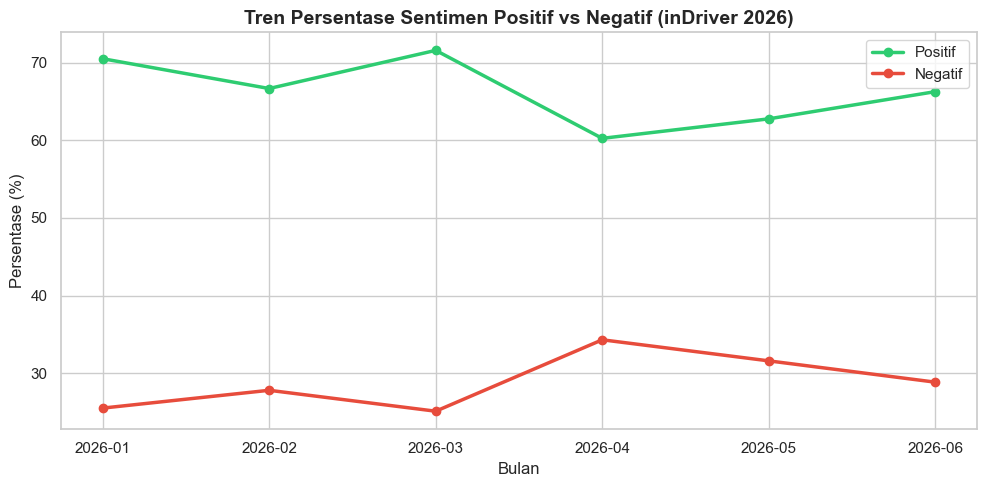

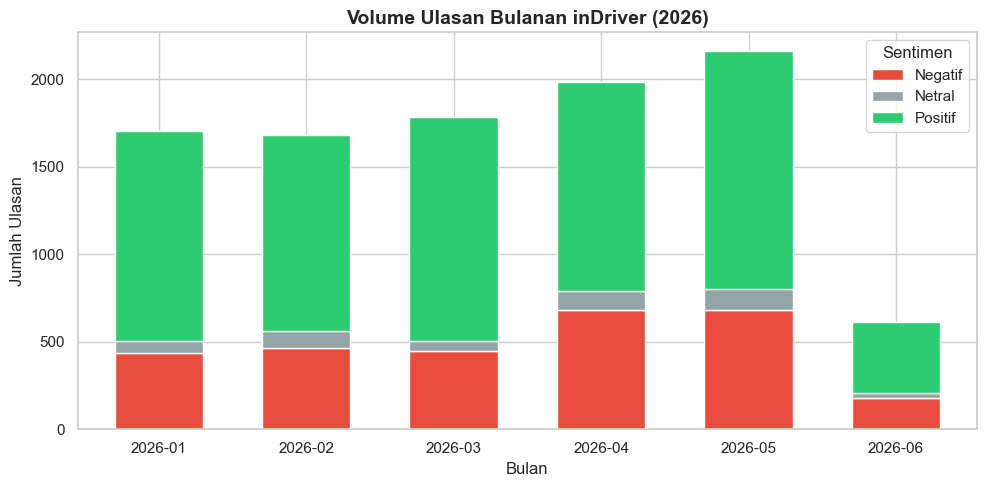

In [8]:
def get_sentiment(score):
    if score in [1, 2]:
        return 'Negatif'
    elif score == 3:
        return 'Netral'
    else:
        return 'Positif'

df['sentiment'] = df['score'].apply(get_sentiment)
df['month'] = df['at'].dt.to_period('M')

# Rekap volume & persentase bulanan
temporal_counts = df.groupby(['month', 'sentiment']).size().unstack(fill_value=0)
temporal_pct = temporal_counts.div(temporal_counts.sum(axis=1), axis=0) * 100

print("Volume Ulasan per Bulan:")
print(temporal_counts)
print("\nPersentase Sentimen per Bulan:")
print(temporal_pct.round(2))

# Visualisasi 1: Line Chart Tren Persentase Positif vs Negatif
plt.figure(figsize=(10, 5))
plt.plot(temporal_pct.index.astype(str), temporal_pct['Positif'], marker='o', color='#2ecc71', linewidth=2.5, label='Positif')
plt.plot(temporal_pct.index.astype(str), temporal_pct['Negatif'], marker='o', color='#e74c3c', linewidth=2.5, label='Negatif')
plt.title('Tren Persentase Sentimen Positif vs Negatif (inDriver 2026)', fontsize=14, fontweight='bold')
plt.xlabel('Bulan')
plt.ylabel('Persentase (%)')
plt.legend()
plt.tight_layout()
plt.savefig('plots/tren_sentimen_bulanan.png', dpi=300)
plt.show()

# Visualisasi 2: Bar Chart Volume Ulasan per Bulan
plt.figure(figsize=(10, 5))
temporal_counts.plot(kind='bar', stacked=True, color=['#e74c3c', '#95a5a6', '#2ecc71'], width=0.6, ax=plt.gca())
plt.title('Volume Ulasan Bulanan inDriver (2026)', fontsize=14, fontweight='bold')
plt.xlabel('Bulan')
plt.ylabel('Jumlah Ulasan')
plt.xticks(rotation=0)
plt.legend(title='Sentimen')
plt.tight_layout()
plt.savefig('plots/volume_ulasan_bulanan.png', dpi=300)
plt.show()

# Analisis Berbasis Versi Aplikasi (RM-1 & RM-2 - Prompt 3)

Mengidentifikasi performa aplikasi berdasarkan rilis versi (reviewCreatedVersion), mencari versi bermasalah, dan kata kunci negatif yang mendominasi versi tersebut.

Top 3 Versi Terburuk Berdasarkan Rating:
reviewCreatedVersion  avg_score  count_reviews  negative_reviews
             5.168.0   2.000000             14                10
             5.164.0   3.064665            433               195
             5.159.0   3.100000             10                 5


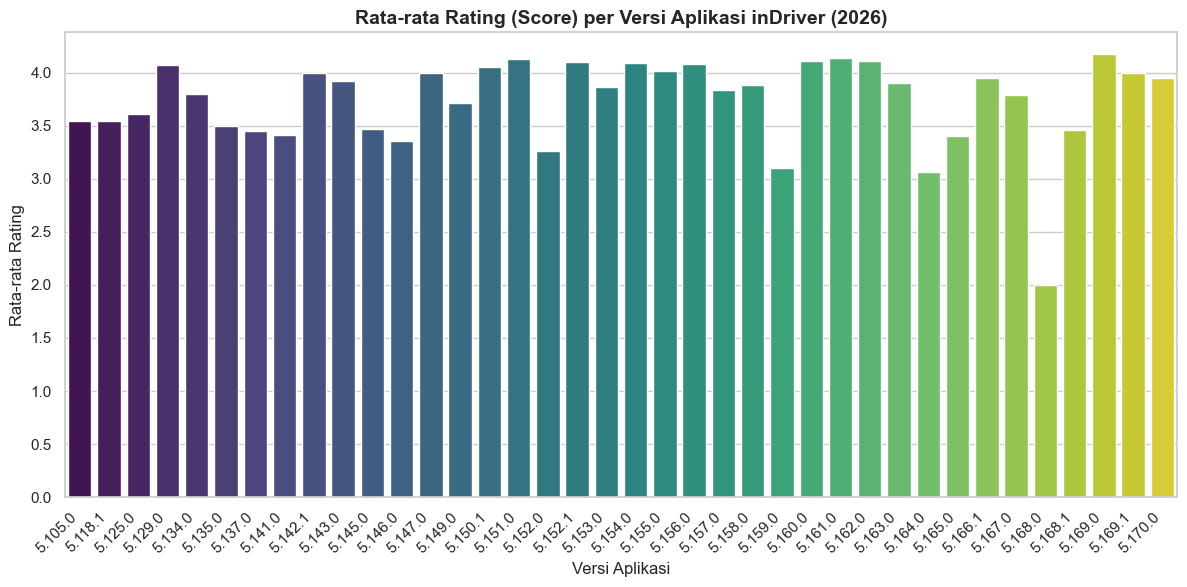

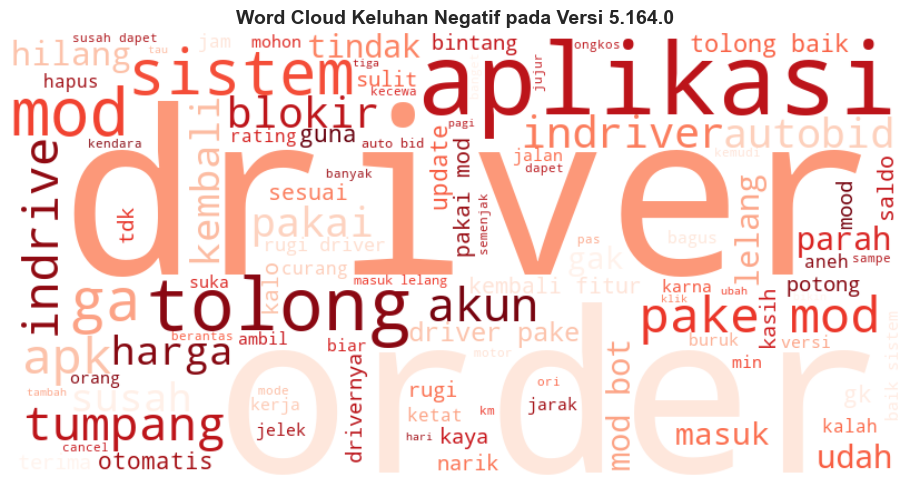

In [9]:
version_stats = df.groupby('reviewCreatedVersion').agg(
    avg_score=('score', 'mean'),
    count_reviews=('score', 'count'),
    negative_reviews=('sentiment', lambda x: (x == 'Negatif').sum())
).reset_index()

# Filter versi dengan minimal 10 ulasan untuk analisis yang lebih andal
version_stats_filtered = version_stats[version_stats['count_reviews'] >= 10].sort_values(by='avg_score')

top_3_worst = version_stats_filtered.head(3)
print("Top 3 Versi Terburuk Berdasarkan Rating:")
print(top_3_worst.to_string(index=False))

# Plot rating rata-rata per versi (untuk versi dengan >= 10 ulasan)
plt.figure(figsize=(12, 6))
version_stats_sorted = version_stats_filtered.sort_values(by='reviewCreatedVersion')
sns.barplot(data=version_stats_sorted, x='reviewCreatedVersion', y='avg_score', palette='viridis')
plt.title('Rata-rata Rating (Score) per Versi Aplikasi inDriver (2026)', fontsize=14, fontweight='bold')
plt.xlabel('Versi Aplikasi')
plt.ylabel('Rata-rata Rating')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('plots/rating_per_versi.png', dpi=300)
plt.show()

# Visualisasi WordCloud untuk Versi Terburuk (contoh: 5.164.0 yang memiliki banyak ulasan)
worst_ver = "5.164.0"
worst_texts = df[(df['reviewCreatedVersion'] == worst_ver) & (df['sentiment'] == 'Negatif')]['content_clean']
text_combined = " ".join(worst_texts)

wordcloud = WordCloud(width=800, height=400, background_color='white', max_words=100, colormap='Reds').generate(text_combined)

plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title(f'Word Cloud Keluhan Negatif pada Versi {worst_ver}', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(f'plots/wordcloud_version_{worst_ver}.png', dpi=300)
plt.show()

# Analisis Aspek Bisnis dengan ABSA (RM-3 - Prompt 4)

Melakukan Aspect-Based Sentiment Analysis sederhana berbasis kamus kata kunci pada aspek Bisnis: Harga, Driver, Promo, Keamanan, Aplikasi, Customer Service.

Distribusi Sentimen per Aspek Layanan:
sentiment         Negatif  Netral  Positif
aspects                                   
Aplikasi              231      44      123
Customer Service      170      22      136
Driver               1244     174      832
Harga                 438      65      507
Keamanan               91      13      268
Promo                  11       2       13

Persentase Sentimen per Aspek Layanan (%):
sentiment         Negatif  Netral  Positif
aspects                                   
Aplikasi            58.04   11.06    30.90
Customer Service    51.83    6.71    41.46
Driver              55.29    7.73    36.98
Harga               43.37    6.44    50.20
Keamanan            24.46    3.49    72.04
Promo               42.31    7.69    50.00


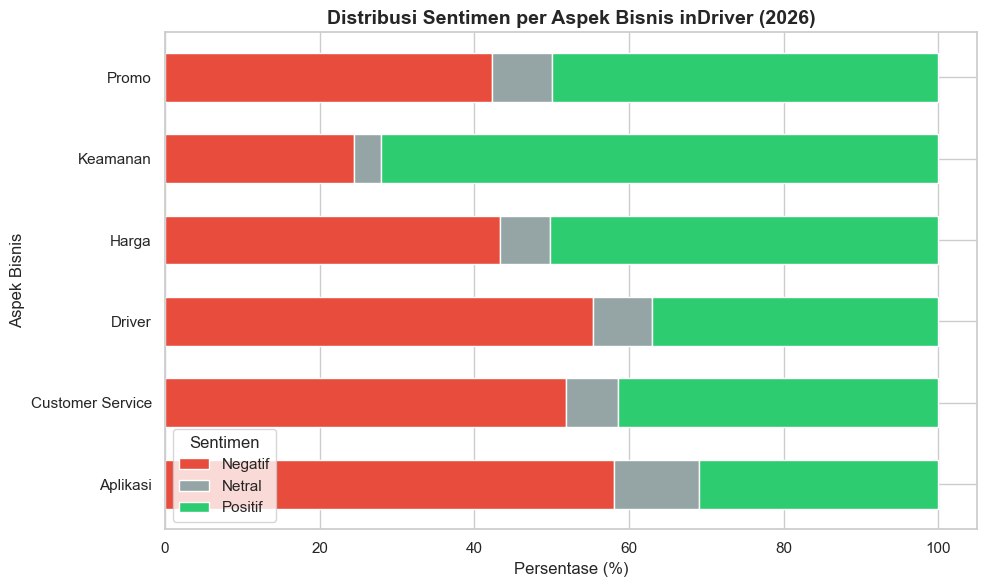

In [10]:
aspect_dict = {
    'Harga': ["mahal", "murah", "tarif", "biaya", "argo", "harga", "bayar"],
    'Driver': ["driver", "pengemudi", "sopir", "ojek", "mitra"],
    'Promo': ["promo", "diskon", "voucher", "cashback", "kode promo"],
    'Keamanan': ["aman", "bahaya", "keamanan", "tracking", "berbahaya", "serem"],
    'Aplikasi': ["crash", "error", "bug", "lemot", "loading", "force close", "update"],
    'Customer Service': ["cs", "customer service", "admin", "respon", "komplain", "lapor"]
}

def match_aspects(text):
    matched = []
    for aspect, keywords in aspect_dict.items():
        for kw in keywords:
            if kw in text:
                matched.append(aspect)
                break
    return matched

df['aspects'] = df['content_clean'].apply(match_aspects)

# Explode list aspek
df_aspect = df.explode('aspects').dropna(subset=['aspects'])

# Hitung persentase sentimen per aspek
aspect_counts = df_aspect.groupby(['aspects', 'sentiment']).size().unstack(fill_value=0)
aspect_pct = aspect_counts.div(aspect_counts.sum(axis=1), axis=0) * 100

print("Distribusi Sentimen per Aspek Layanan:")
print(aspect_counts)
print("\nPersentase Sentimen per Aspek Layanan (%):")
print(aspect_pct.round(2))

# Visualisasi Stacked Bar Chart
plt.figure(figsize=(10, 6))
aspect_pct.plot(kind='barh', stacked=True, color=['#e74c3c', '#95a5a6', '#2ecc71'], width=0.6, ax=plt.gca())
plt.title('Distribusi Sentimen per Aspek Bisnis inDriver (2026)', fontsize=14, fontweight='bold')
plt.xlabel('Persentase (%)')
plt.ylabel('Aspek Bisnis')
plt.legend(title='Sentimen', loc='lower left')
plt.tight_layout()
plt.savefig('plots/sentimen_per_aspek.png', dpi=300)
plt.show()

# Analisis Responsivitas Customer Service (RM-5 - Prompt 5)

Mengukur persentase ulasan dibalas dan waktu respons CS untuk ulasan rating rendah (Negatif) vs ulasan rating tinggi (Positif). Kita akan memfilter nilai response_time_hours < 0 karena itu merupakan anomali data (waktu balasan sebelum ulasan dibuat).

Statistik Respons Customer Service:
 rating_group  total_reviews  replied_count  avg_response_hours  median_response_hours  reply_rate_pct
Negatif (1-2)           2888           2862           12.599895               1.965556           99.10
   Netral (3)            480            473           10.493007               1.999583           98.54
Positif (4-5)           6559            905            6.976236               1.919583           13.80


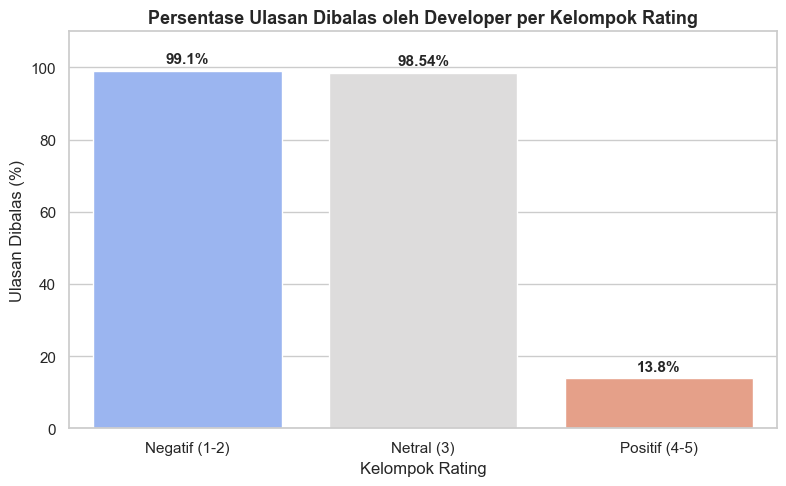

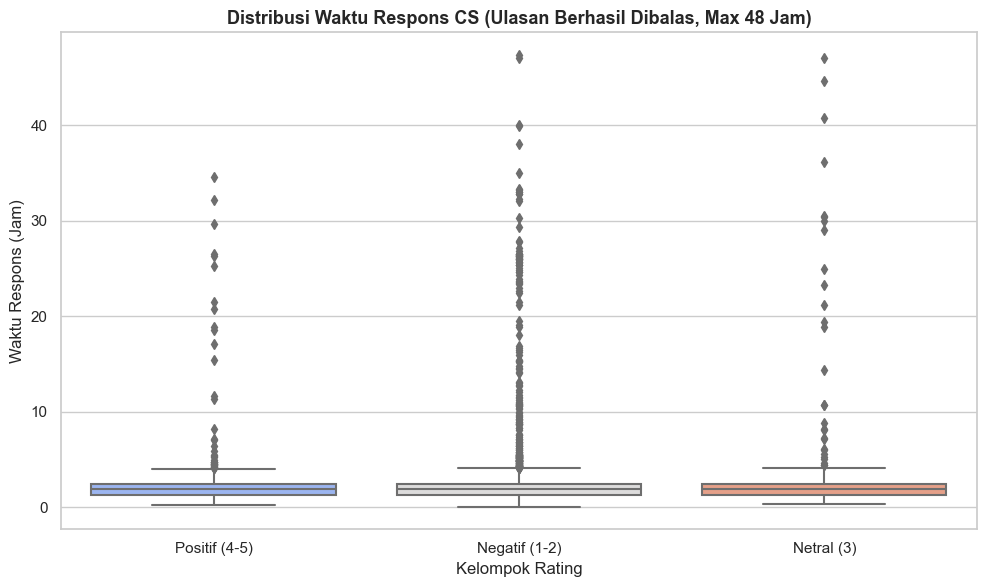

In [11]:
# Buat kelompok rating
def get_rating_group(score):
    if score in [1, 2]:
        return 'Negatif (1-2)'
    elif score == 3:
        return 'Netral (3)'
    else:
        return 'Positif (4-5)'

df['rating_group'] = df['score'].apply(get_rating_group)

# Hapus anomali response time negatif untuk rata-rata
df_cs_clean = df.copy()
df_cs_clean.loc[df_cs_clean['response_time_hours'] < 0, 'response_time_hours'] = None

cs_stats = df_cs_clean.groupby('rating_group').agg(
    total_reviews=('score', 'count'),
    replied_count=('is_replied', 'sum'),
    avg_response_hours=('response_time_hours', 'mean'),
    median_response_hours=('response_time_hours', 'median')
).reset_index()

cs_stats['reply_rate_pct'] = (cs_stats['replied_count'] / cs_stats['total_reviews'] * 100).round(2)
print("Statistik Respons Customer Service:")
print(cs_stats.to_string(index=False))

# Visualisasi 1: Bar Chart Persentase Dibalas
plt.figure(figsize=(8, 5))
sns.barplot(data=cs_stats, x='rating_group', y='reply_rate_pct', palette='coolwarm')
plt.title('Persentase Ulasan Dibalas oleh Developer per Kelompok Rating', fontsize=13, fontweight='bold')
plt.xlabel('Kelompok Rating')
plt.ylabel('Ulasan Dibalas (%)')
plt.ylim(0, 110)
for idx, row in cs_stats.iterrows():
    plt.text(idx, row['reply_rate_pct'] + 2, f"{row['reply_rate_pct']}%", ha='center', fontweight='bold')
plt.tight_layout()
plt.savefig('plots/cs_reply_rate.png', dpi=300)
plt.show()

# Visualisasi 2: Box Plot Distribusi Response Time (Filter < 48 jam untuk keterbacaan)
plt.figure(figsize=(10, 6))
df_filtered_time = df_cs_clean[(df_cs_clean['response_time_hours'] >= 0) & (df_cs_clean['response_time_hours'] <= 48)]
sns.boxplot(data=df_filtered_time, x='rating_group', y='response_time_hours', palette='coolwarm')
plt.title('Distribusi Waktu Respons CS (Ulasan Berhasil Dibalas, Max 48 Jam)', fontsize=13, fontweight='bold')
plt.xlabel('Kelompok Rating')
plt.ylabel('Waktu Respons (Jam)')
plt.tight_layout()
plt.savefig('plots/cs_response_time_distribution.png', dpi=300)
plt.show()

# Analisis Isu Sistemik dari Thumbs Up Tinggi (RM-6 - Prompt 6)

Menganalisis ulasan yang mendapat banyak likes/thumbs up dari pengguna lain untuk melihat apakah ada keluhan sistemik yang tidak/belum direspon oleh pihak inDriver.

Batas 95th Percentile untuk Thumbs Up: 2.0
Jumlah ulasan di top 5% thumbsUpCount: 673
Jumlah yang belum dibalas: 121 (17.98%)

20 Kata Kunci Keluhan Terpopuler yang Belum Dibalas:
- driver: 86 kali
- order: 78 kali
- tolong: 64 kali
- aplikasi: 45 kali
- indrive: 41 kali
- tumpang: 36 kali
- akun: 32 kali
- sistem: 30 kali
- baik: 27 kali
- masuk: 25 kali
- jarak: 25 kali
- indriver: 23 kali
- mohon: 22 kali
- fitur: 21 kali
- autobid: 21 kali
- harga: 20 kali
- mod: 20 kali
- terima: 20 kali
- jalan: 20 kali
- jemput: 19 kali


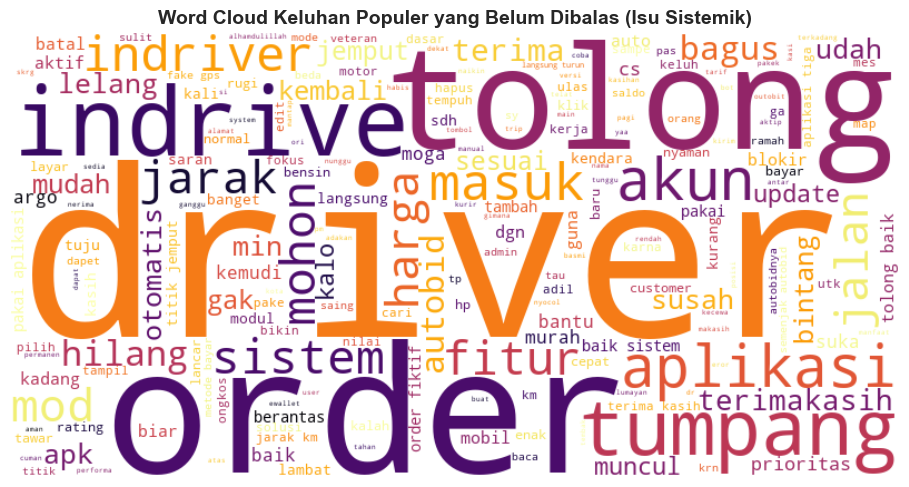


5 Contoh Ulasan Populer yang Belum Dibalas:

[ThumbsUp: 458 | Score: 5]
Ulasan: kenapa sistem IT indrive sering sekali mengotak atik autobid nya,yang harus di hilangkan itu yang pakai mod,terus cs cs nakal yang memesan orderan palsu bukannya sistem yang udah bagus tapi di otak atik,HERANNNNNNN🤦🤦🤦🤦🤦🤦

[ThumbsUp: 347 | Score: 5]
Ulasan: Tolonglah pihak indrive memperbaiki sistem, banyak sekali di lapangan saya temuin yg pakai aplikasi pihak ketiga untuk ambil orderan. Belum lagi skenario driver" yg suka tembak perjalanan dan membuat orderan fiktif untuk mengganggu akun driver lain.

[ThumbsUp: 171 | Score: 5]
Ulasan: semenjak updet baru min kok outobit nya hilang. kan , padahal outobit bisa, membantu setiap pengemudi dalam, mencari orderan!. dan pastinya banyak, yg ngelu, karna sistem yg di ubah. apalagi kalau HP yg di pakai kurang performa, pasti orderan nya lama masuk,. mohon keluhan, pengemudi di pertimbangan kan, min !.. TERIMAKASIH! 🙏

[ThumbsUp: 157 | Score: 5]
Ulasan: di mohon ke

In [12]:
percentile_95 = df['thumbsUpCount'].quantile(0.95)
print(f"Batas 95th Percentile untuk Thumbs Up: {percentile_95}")

top_thumbs = df[df['thumbsUpCount'] >= percentile_95]
not_replied_top = top_thumbs[top_thumbs['is_replied'] == False]

print(f"Jumlah ulasan di top 5% thumbsUpCount: {len(top_thumbs)}")
print(f"Jumlah yang belum dibalas: {len(not_replied_top)} ({len(not_replied_top)/len(top_thumbs)*100:.2f}%)")

# Ekstrak 20 kata kunci teratas dari ulasan populer yang BELUM dibalas
all_words = []
for text in not_replied_top['content_clean']:
    all_words.extend(text.split())
    
word_counts = Counter(all_words)
print("\n20 Kata Kunci Keluhan Terpopuler yang Belum Dibalas:")
for word, count in word_counts.most_common(20):
    print(f"- {word}: {count} kali")

# Visualisasi WordCloud Ulasan Populer Belum Dibalas
wordcloud_pop = WordCloud(width=800, height=400, background_color='white', colormap='inferno').generate(" ".join(not_replied_top['content_clean']))
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud_pop, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud Keluhan Populer yang Belum Dibalas (Isu Sistemik)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('plots/wordcloud_systemic_issues.png', dpi=300)
plt.show()

# Tampilkan 5 contoh ulasan populer teratas yang belum dibalas
print("\n5 Contoh Ulasan Populer yang Belum Dibalas:")
for i, row in not_replied_top.sort_values(by='thumbsUpCount', ascending=False).head(5).iterrows():
    print(f"\n[ThumbsUp: {row['thumbsUpCount']} | Score: {row['score']}]\nUlasan: {row['content']}")